In [1]:
from importlib import reload
import os
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.insert(0, r"../main_code/3d")
for _mod in ['generate_data', 'mesh', 'adaptive_int', 'visual', 'matrix_assemble', 'inverse_solver', 'mea_3d', 'net_3d', 'source_eval', 'error_general_3d', 'main', 'bound_detect', 'q_filter']:
    sys.modules.pop(_mod, None)
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_3d,net_3d,source_eval,error_general_3d,main
CUDA_LAUNCH_BLOCKING=2

input_dir = "./noise=5%"
output_dir = "./noise=5%"
os.makedirs(output_dir, exist_ok=True)

def f_y(x, x_min,x_max,y_min,y_max,z_min,z_max,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1) 
    
    # Apply the piecewise function
    f_y_values = np.where(r_y < r, r - r_y, 0.0)
    return f_y_values

def ana_S(x,x_min,x_max,y_min,y_max,z_min,z_max,a,b,r): # x is the data array; a and b are center coordinates
    return f_y(x,x_min,x_max,y_min,y_max,z_min,z_max,a,r)-f_y(x,x_min,x_max,y_min,y_max,z_min,z_max,b,r)


cuda:4


In [2]:
import copy
Nx,Ny,Nz=1,1,1
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81]
tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max=0,1,0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max=-0.5,1.5,-0.5,1.5,-0.5,1.5 # On boundary Gamma
num_batches_gauss=1
b_n=10
points_b=mea_3d.generate_cube_surface(b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max,b_n) # Collect data on boundary Gamma
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.15
center_1=np.array([0.3,0.5,0.3])
center_2=np.array([0.5,0.5,0.8])
center_true=np.array([[0.3,0.5,0.3],[0.5,0.5,0.8]])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
num_batches_gauss=4
num_batches_appr=10
num_batches_mea=1
cupy_device = device.index if device.type == "cuda" else 0

In [3]:
F_81_5_15=np.load(f"{input_dir}/F_81_5%.npy")

In [4]:
M=3600
af="Tanh"   # Initial activation setting
R_m=10
models0 = net_3d.local_rep(in_features=3, out_features=1, hidden_layers=1, M=M, x_max=1, x_min=0, y_max=1, y_min=0,z_min=0,z_max=1, r_min=[], r_max=[],b1_min=[],b1_max=[],b2_min=[],b2_max=[],b3_min=[],b3_max=[],peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=[],K_max=[],R_m_for_init=R_m,af=af,device=device).to(device)

Plotting 64 cells. Levels: 0 to 0


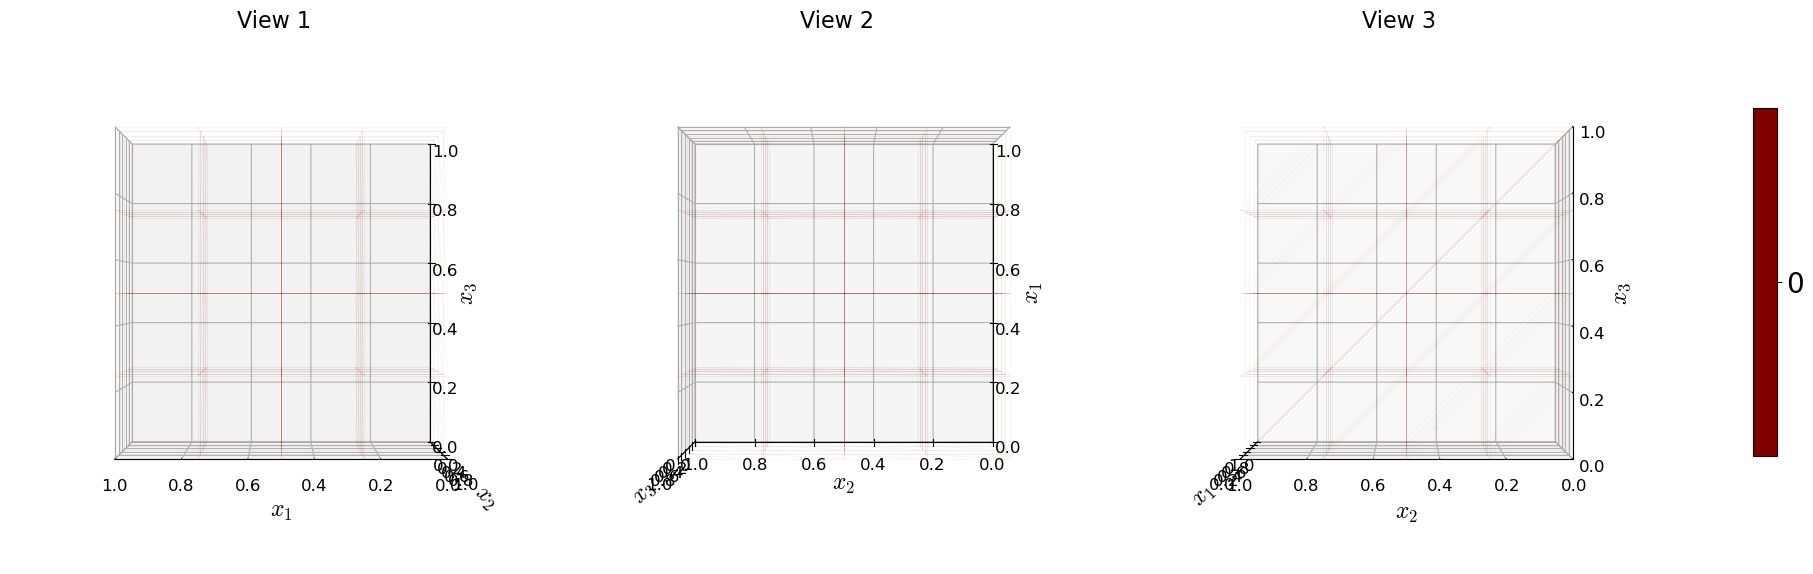

/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1241: RuntimeWarning: invalid value encountered in divide
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1278: RuntimeWarning: divide by zero encountered in scalar divide
  a = -1.5 / ax_dx
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1279: RuntimeWarning: divide by zero encountered in scalar divide
  b = 2. / ax_dx
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1280: RuntimeWarning: divide by zero encountered in scalar divide
  c = -0.5 / ax_dx
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1288: RuntimeWarning: invalid value encountered in scalar add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(

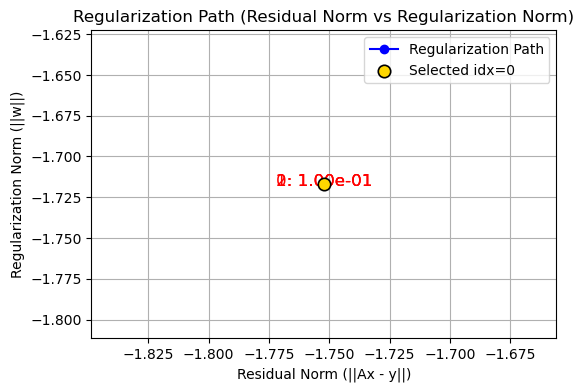

L-curve corner index: 0
Selected lambda by curvature: 1.000000e-01
  idx=0, lambda=1.000000e-01, curvature=0.000000e+00
  idx=1, lambda=1.000000e-01, curvature=0.000000e+00
  idx=2, lambda=1.000000e-01, curvature=0.000000e+00
Top curvature candidates:
  rank=1, idx=1, lambda=1.000000e-01, curvature=0.000000e+00
Training error at iteration 0 :
S_l_inf= 7.28092667072417 S_L_2= 0.006211105118000125 S_l_2= 0.6672392153658794
Generalization error at iteration 0 :
S_l_inf= 13.886662615293762 S_L_2= 0.005557059094312596 S_l_2= 0.7071848573466633


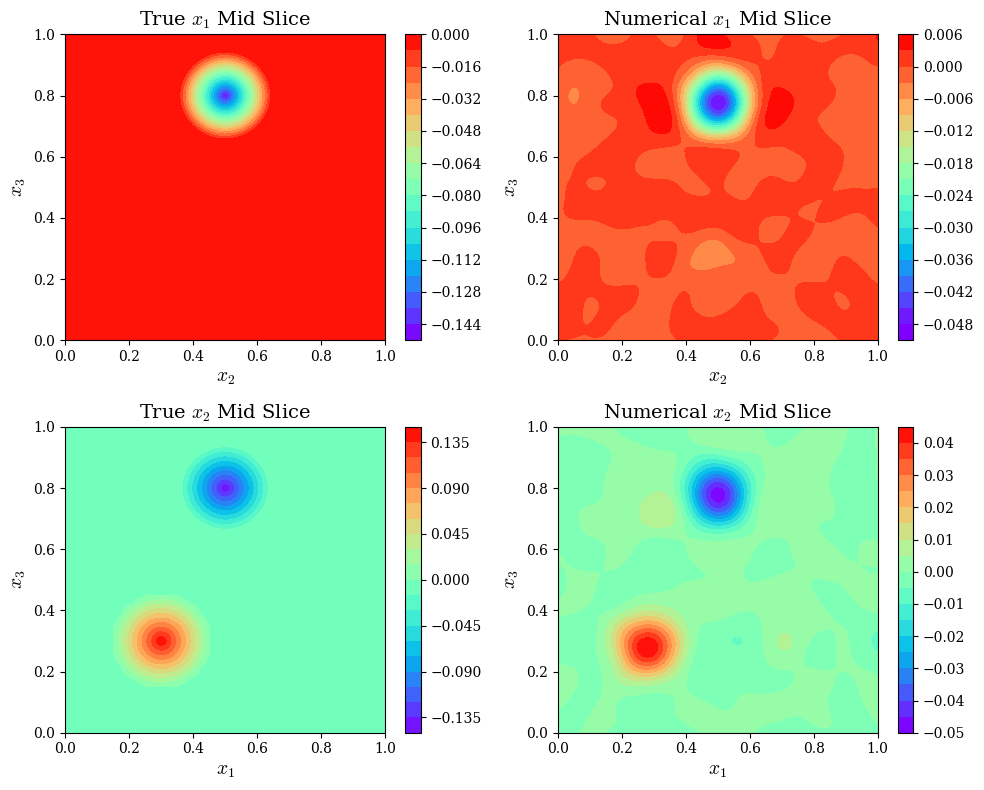

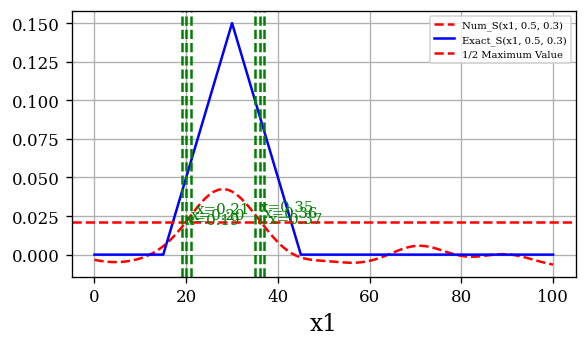

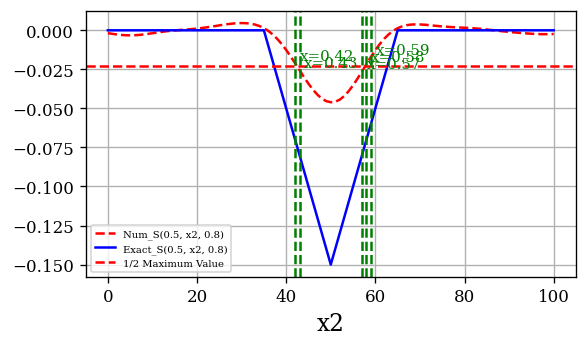

Adaptive mesh refinement at iteration 0 ...
Current number of cells: 512
Plotting 512 cells. Levels: 1 to 1


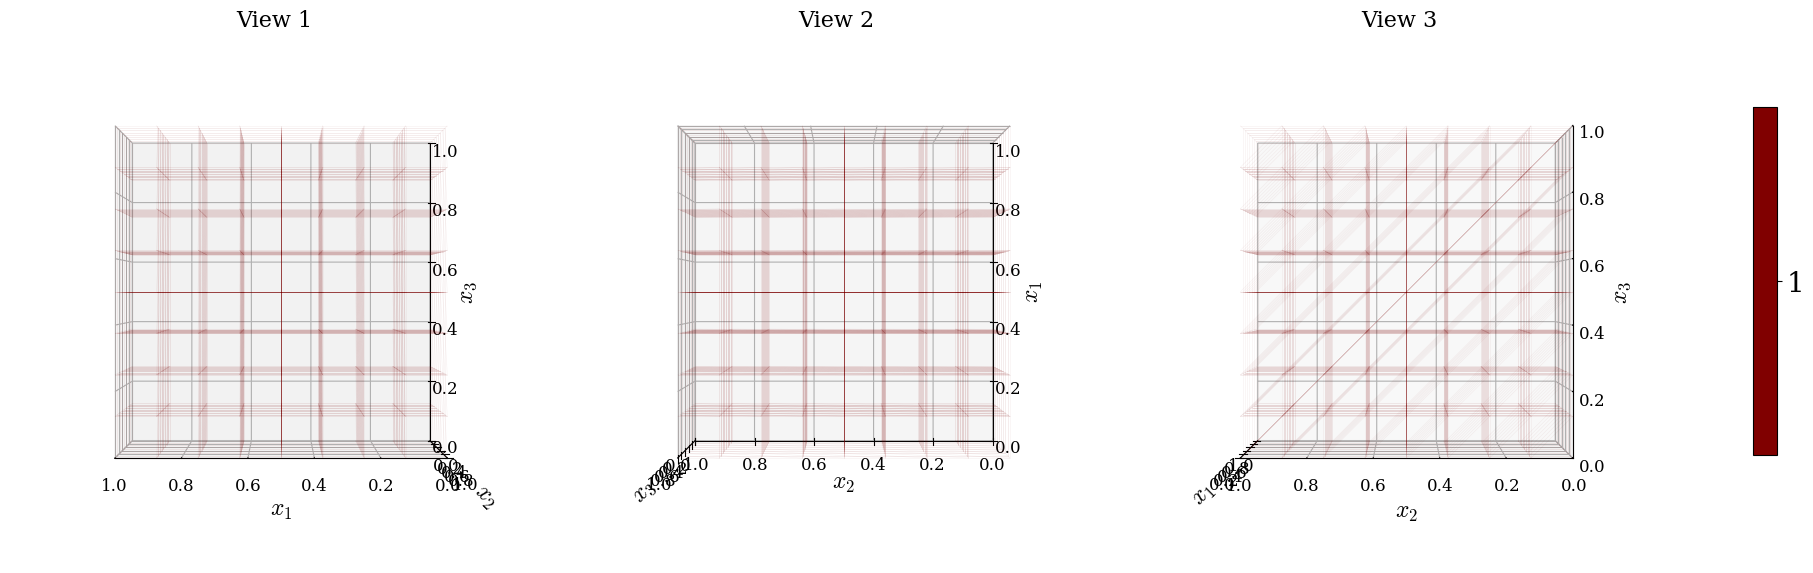

/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1241: RuntimeWarning: invalid value encountered in divide
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1278: RuntimeWarning: divide by zero encountered in scalar divide
  a = -1.5 / ax_dx
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1279: RuntimeWarning: divide by zero encountered in scalar divide
  b = 2. / ax_dx
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1280: RuntimeWarning: divide by zero encountered in scalar divide
  c = -0.5 / ax_dx
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1288: RuntimeWarning: invalid value encountered in scalar add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(

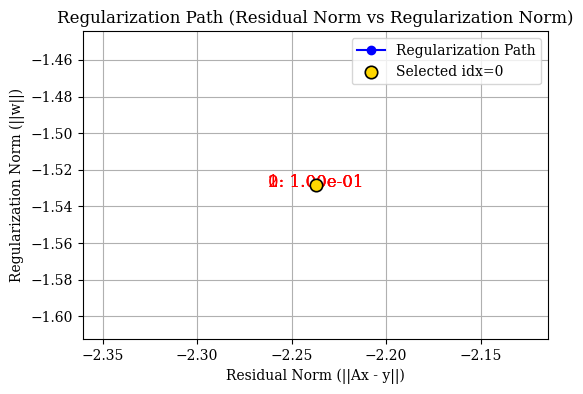

L-curve corner index: 0
Selected lambda by curvature: 1.000000e-01
  idx=0, lambda=1.000000e-01, curvature=0.000000e+00
  idx=1, lambda=1.000000e-01, curvature=0.000000e+00
  idx=2, lambda=1.000000e-01, curvature=0.000000e+00
Top curvature candidates:
  rank=1, idx=1, lambda=1.000000e-01, curvature=0.000000e+00
Training error at iteration 1 :
S_l_inf= 2.9558696421828894 S_L_2= 0.0017267430485107833 S_l_2= 0.21606629323180898
Generalization error at iteration 1 :
S_l_inf= 5.378844827546279 S_L_2= 0.001700450517304026 S_l_2= 0.21639734904662908


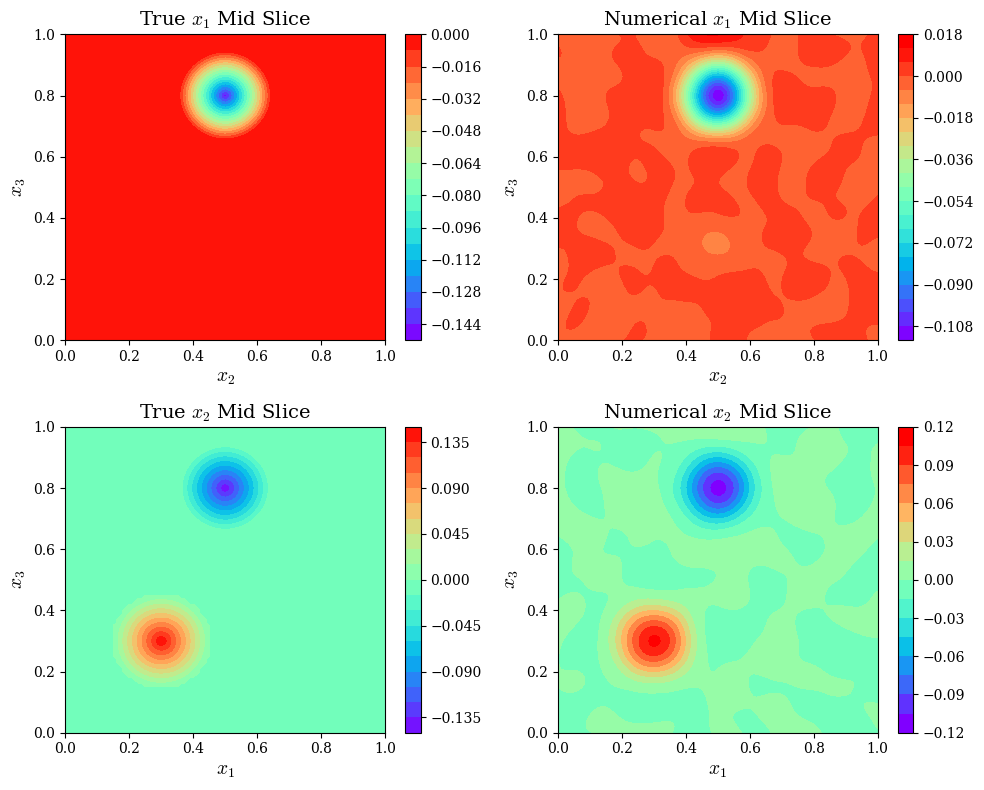

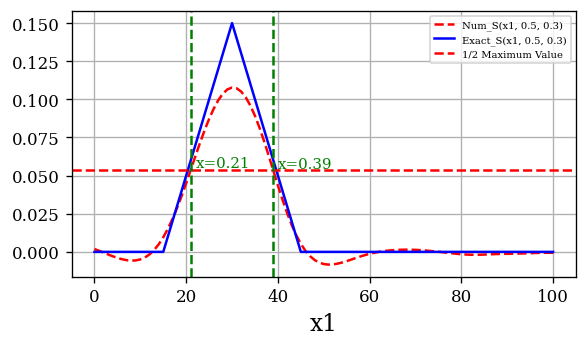

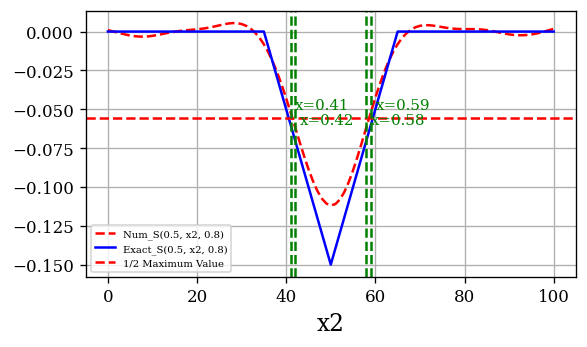

Adaptive mesh refinement at iteration 1 ...
Current number of cells: 813
Plotting 813 cells. Levels: 1 to 2


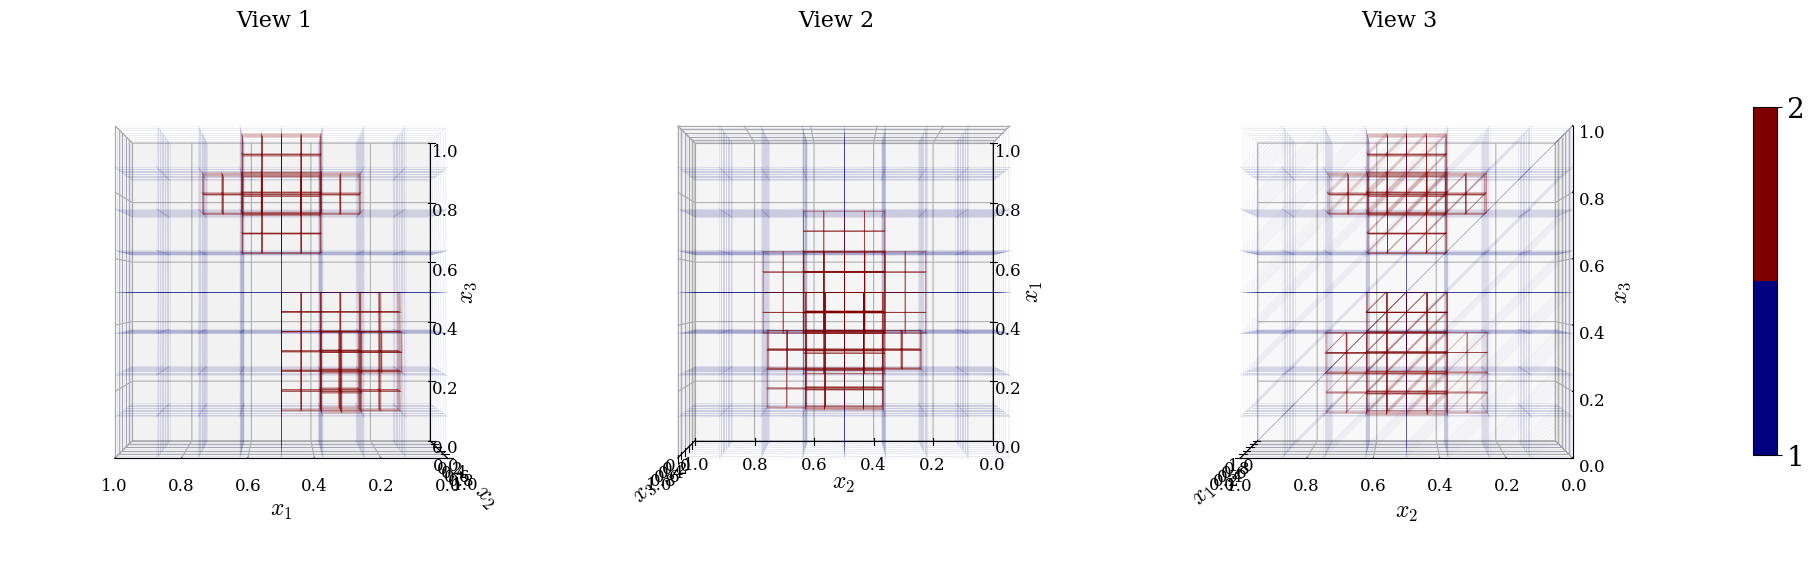

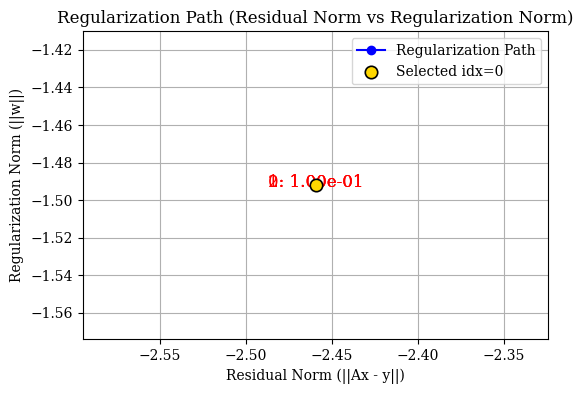

L-curve corner index: 0
Selected lambda by curvature: 1.000000e-01
  idx=0, lambda=1.000000e-01, curvature=0.000000e+00
  idx=1, lambda=1.000000e-01, curvature=0.000000e+00
  idx=2, lambda=1.000000e-01, curvature=0.000000e+00
Top curvature candidates:
  rank=1, idx=1, lambda=1.000000e-01, curvature=0.000000e+00
Training error at iteration 2 :
S_l_inf= 1.3117269749254044 S_L_2= 0.0024465728631386124 S_l_2= 0.13660322180015122
Generalization error at iteration 2 :
S_l_inf= 4.1824488449154265 S_L_2= 0.0013388230355318434 S_l_2= 0.17037705759940835


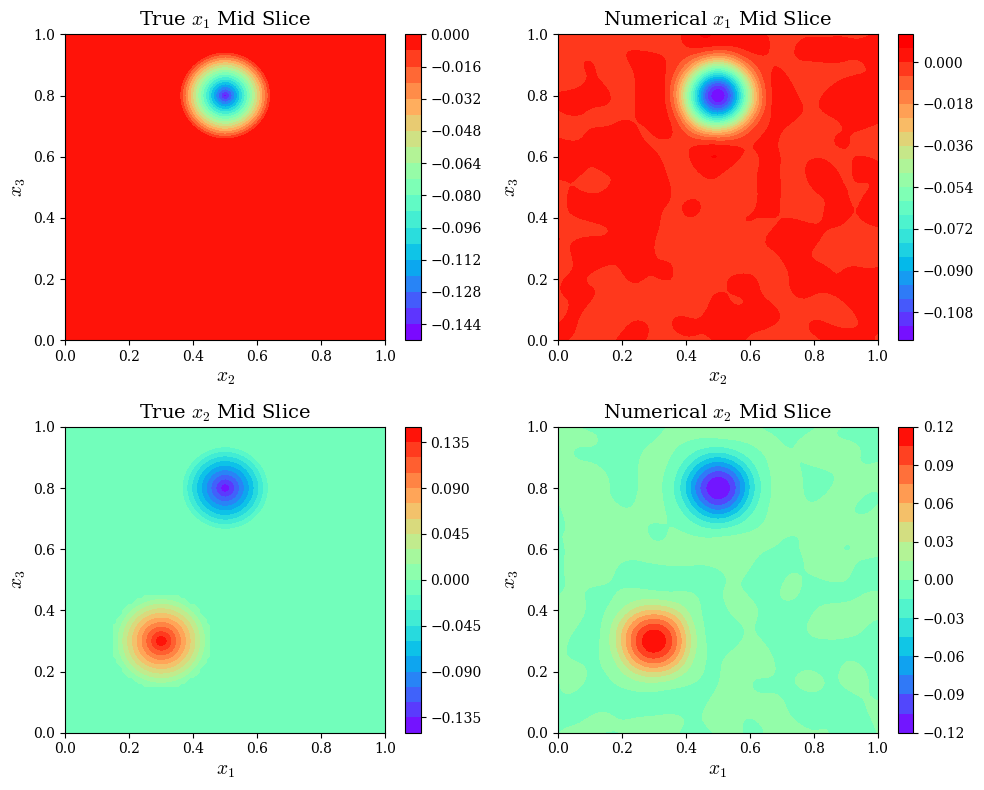

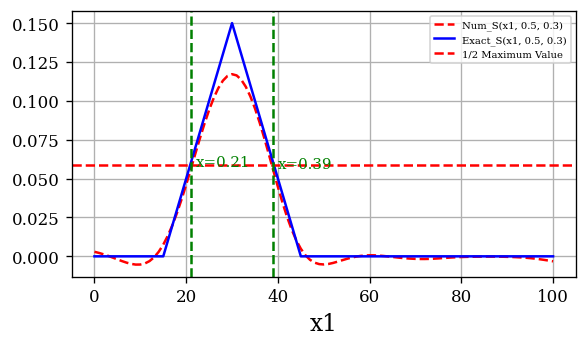

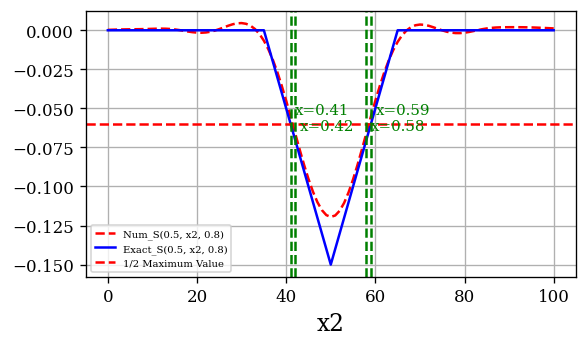

Adaptive mesh refinement at iteration 2 ...
Current number of cells: 1443


In [5]:
Ix,Iy,Iz=4,4,4  # Number of grid cells in the x direction
nx,ny,nz=3,3,3  # Gauss points per cell in the x direction
cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,Ix,nx,points_b) # Create the initial grid
initial_cells=copy.deepcopy(cells) # Make a copy
delta=10**(-3)
lamb_regu=np.logspace(-1,-1,3)

Qx,Qy,Qz=50,50,50
iter_int=3
max_level=4
current_maxiter=1
refine_threshold_S = 1/100
refine_threshold_grad = 1/300
ratio1=[0.3,0.5,0.3]
ratio2=[0.5,0.5,0.8]
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_num_store,S_basis=main.ada_int(iter_int,delta,cells,nx,models0,M,"Tanh",kk,F_81_5_15,tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,Qz,ratio1,ratio2,device,cupy_device,refine_threshold_S,refine_threshold_grad,current_maxiter,max_level)

In [6]:
import pickle
output_pickle_file = f"{output_dir}/cells_store.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(cells_store,f)
torch.save(models0, f'{output_dir}/model_tanh.pth')
np.save(f"{output_dir}/S_basis.npy",S_basis, allow_pickle=True)
np.save(f"{output_dir}/g_S.npy",g_S)
np.save(f"{output_dir}/S_num_store.npy",S_num_store, allow_pickle=True)

In [5]:
g_S=np.load(f"{input_dir}/g_S.npy")
S_num_store=np.load(f"{input_dir}/S_num_store.npy",allow_pickle=True)
S_basis=np.load(f"{input_dir}/S_basis.npy",allow_pickle=True)
models0=torch.load(f"{input_dir}/model_tanh.pth", map_location=device)
import pickle 
with open(f"{input_dir}/cells_store.pkl", 'rb') as f: # 'rb' for read binary
    cells_store = pickle.load(f)

Grid shape from g_S: 101x101x101
DBSCAN eps = 0.050000 (5.000000 * h, h = 0.010000)
Number of detected clusters: 2
  CV of S_num (geometry_interior, n=15570): 0.739
Cluster 0: AR=1.07
  Res_Rect=0.157451 vs Res_Ellip=0.037324 vs Res_Tori=0.093770
  center=(0.3000, 0.5009, 0.2991)
  Lx=0.310000, Ly=0.300000, Lz=0.320000
  dist_01=0.036188, dist_99=0.160010
  half-axes=(0.155000, 0.150000, 0.160000)
  -> Decision: Ellipsoid (Exp)
  CV of S_num (geometry_interior, n=17125): 0.818
Cluster 1: AR=1.00
  Res_Rect=0.183625 vs Res_Ellip=0.024043 vs Res_Tori=0.094407
  center=(0.4991, 0.4994, 0.8000)
  Lx=0.320000, Ly=0.320000, Lz=0.320000
  dist_01=0.035726, dist_99=0.159158
  half-axes=(0.160000, 0.160000, 0.160000)
  -> Decision: Ellipsoid (Exp)


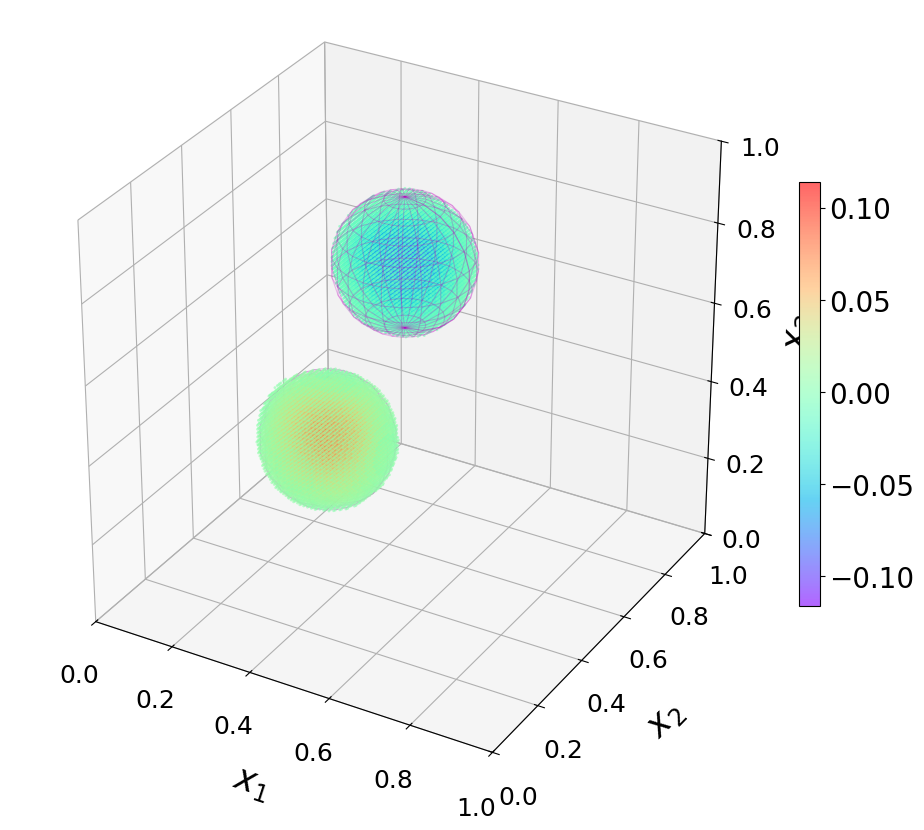

LaTeX table rows:
{\emph{Ex}} & Cluster $k$ & $\boldsymbol{c}_k$ & $r_k$ or $\boldsymbol{L}_k$ & $\mathcal{E}_{\mathrm{rect}}^{(k)}$ & $\mathcal{E}_{\mathrm{ellip}}^{(k)}$ & $\mathcal{E}_{\mathrm{tori}}^{(k)}$ & $\mathrm{AR}_k$ & $\mathrm{CV}_k$ & $\mathcal{T}_k$ & $\sigma_k$ \\
\multirow{2}{*}{Ex 4.8} & 1 & (3.00e-01, 5.01e-01, 2.99e-01) & $\boldsymbol{L}$=(1.55e-01, 1.50e-01, 1.60e-01) & 0.1575 & 0.0373 & 0.0938 & 1.07 & 0.739 & \textbf{Ellipsoid} & Exp \\
 & 2 & (4.99e-01, 4.99e-01, 8.00e-01) & $\boldsymbol{L}$=(1.60e-01, 1.60e-01, 1.60e-01) & 0.1836 & 0.0240 & 0.0944 & 1.00 & 0.818 & \textbf{Ellipsoid} & Exp \\


['LaTeX table rows:',
 '{\\emph{Ex}} & Cluster $k$ & $\\boldsymbol{c}_k$ & $r_k$ or $\\boldsymbol{L}_k$ & $\\mathcal{E}_{\\mathrm{rect}}^{(k)}$ & $\\mathcal{E}_{\\mathrm{ellip}}^{(k)}$ & $\\mathcal{E}_{\\mathrm{tori}}^{(k)}$ & $\\mathrm{AR}_k$ & $\\mathrm{CV}_k$ & $\\mathcal{T}_k$ & $\\sigma_k$ \\\\',
 '\\multirow{2}{*}{Ex 4.8} & 1 & (3.00e-01, 5.01e-01, 2.99e-01) & $\\boldsymbol{L}$=(1.55e-01, 1.50e-01, 1.60e-01) & 0.1575 & 0.0373 & 0.0938 & 1.07 & 0.739 & \\textbf{Ellipsoid} & Exp \\\\',
 ' & 2 & (4.99e-01, 4.99e-01, 8.00e-01) & $\\boldsymbol{L}$=(1.60e-01, 1.60e-01, 1.60e-01) & 0.1836 & 0.0240 & 0.0944 & 1.00 & 0.818 & \\textbf{Ellipsoid} & Exp \\\\']

In [7]:
from importlib import reload
import bound_detect
reload(bound_detect)

# Dynamically get the shape of g_S to ensure dimension consistency
nx, ny, nz = g_S.shape
print(f"Grid shape from g_S: {nx}x{ny}x{nz}")

x = np.linspace(tau_x_min, tau_x_max, nx)
y = np.linspace(tau_y_min, tau_y_max, ny)
z = np.linspace(tau_z_min, tau_z_max, nz)

# Use indexing='ij' to match matrix indices (row, col, depth) -> (x, y, z)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

eps_cluster=5
mini_samples=20 
para_abs=100

para_grad=3

results = bound_detect.detect_shape_3d(
    g_S, X, Y, Z, 
    tau_x_min, tau_x_max, tau_y_min, tau_y_max, tau_z_min, tau_z_max,
    para_abs, para_grad, eps_cluster, mini_samples, 
    S_num_store[-1], 
    output_directory=output_dir, 
    output_filename="plot.png",
    boundary_margin=(5, 5, 0),
)

bound_detect.print_latex_result_rows_3d(
      results,
      example_name="Ex 4.8",
      include_header=True,
  )


In [8]:
results

[{'cluster_id': 0,
  'shape': 'Ellipsoid',
  'params': {'center': array([0.30003497, 0.50093409, 0.29907954]),
   'a': np.float64(0.155),
   'b': np.float64(0.15),
   'c': np.float64(0.16),
   'radius': 0.1600098230493329},
  'profile': 'Exp',
  'boundary_points': array([[0.1336, 0.4632, 0.3   ],
         [0.1336, 0.4632, 0.3052],
         [0.1336, 0.4632, 0.3104],
         ...,
         [0.4508, 0.5516, 0.2948],
         [0.4508, 0.5516, 0.3   ],
         [0.4508, 0.5516, 0.3052]]),
  'diagnostics': {'Lx': 0.31,
   'Ly': 0.3,
   'Lz': 0.32,
   'aspect_ratio': 1.0666666666666667,
   'res_rect': 0.15745110905143586,
   'res_ellip': 0.037323863100539,
   'res_tori': 0.09377032682777574,
   'res_tori_3d': 0.46408849846224637,
   'res_tori_projection': 0.09377032682777574,
   'residual_threshold': 0.05,
   'boundary_point_count': 17712,
   'torus_point_count': 700,
   'torus_center': array([0.30003497, 0.50093409, 0.29907954]),
   'torus_axis': 0,
   'torus_plane_dims': (1, 2),
   'dist_01

In [9]:
def _local_shape_from_result_3d(item):
    params = item["params"]
    center = np.asarray(params["center"], dtype=float)
    if "a" in params and "b" in params and "c" in params:
        a = float(params["a"])
        b = float(params["b"])
        c = float(params["c"])
    elif "radius" in params:
        a = float(params["radius"])
        b = float(params["radius"])
        c = float(params["radius"])
    elif "R_outer" in params:
        a = float(params["R_outer"])
        b = float(params["R_outer"])
        c = float(params["R_outer"])
    else:
        boundary = np.asarray(item.get("boundary_points", []), dtype=float)
        if boundary.size == 0:
            raise KeyError("No ellipsoid-like parameter or boundary_points in detected result.")
        offsets = boundary - center
        a = 0.5 * (np.max(offsets[:, 0]) - np.min(offsets[:, 0]))
        b = 0.5 * (np.max(offsets[:, 1]) - np.min(offsets[:, 1]))
        c = 0.5 * (np.max(offsets[:, 2]) - np.min(offsets[:, 2]))
    half_axes = np.asarray([a, b, c], dtype=float)
    return center, half_axes

center0, r0 = _local_shape_from_result_3d(results[0])
center1, r1 = _local_shape_from_result_3d(results[1])

In [10]:
r0

array([0.155, 0.15 , 0.16 ])

In [11]:
r1

array([0.16, 0.16, 0.16])

In [12]:
FWHM1=0.18
v1_physical=-(2.355)**2/(2*FWHM1)
FWHM2=0.16
v2_physical=-(2.355)**2/(2*FWHM2)

# The unified net_3d module uses exp(v * metric^2) with a dimensionless ellipsoid metric.
# Convert the legacy dimensional Gaussian exponent to the dimensionless one by
# absorbing the squared characteristic length scale removed from net_3d.py.
char_scale1 = float(np.cbrt(np.prod(r0)))
char_scale2 = float(np.cbrt(np.prod(r1)))
v1 = v1_physical * char_scale1**2
v2 = v2_physical * char_scale2**2


In [13]:
v1_physical, v2_physical, v1, v2

(-15.405625, -17.331328125, -0.36986333565765084, -0.44368199999999997)

In [14]:
v_abs_max = np.max(np.abs([v1, v2]))*2
v_abs_min = np.min(np.abs([v1, v2]))*1/2
v_min = -v_abs_max
v_max = -v_abs_min

In [4]:
import numpy as np
v1=-0.36986333565765084
v2=-0.44368199999999997
v_abs_max = np.max(np.abs([v1, v2]))*2
v_abs_min = np.min(np.abs([v1, v2]))*1/2
v_abs_min,v_abs_max

(np.float64(0.18493166782882542), np.float64(0.8873639999999999))

In [15]:
R_m=10
eps_c=0.05
eps_r=0.05
b1_min1,b1_max1=-center0[0]*(1+eps_c),-center0[0]*(1-eps_c)
b2_min1,b2_max1=-center0[1]*(1+eps_c),-center0[1]*(1-eps_c)
b3_min1,b3_max1=-center0[2]*(1+eps_c),-center0[2]*(1-eps_c)
b1_min2,b1_max2=-center1[0]*(1+eps_c),-center1[0]*(1-eps_c)
b2_min2,b2_max2=-center1[1]*(1+eps_c),-center1[1]*(1-eps_c)
b3_min2,b3_max2=-center1[2]*(1+eps_c),-center1[2]*(1-eps_c)
r1_min = tuple(float(val * (1 - eps_r)) for val in r0)
r1_max = tuple(float(val * (1 + eps_r)) for val in r0)
r2_min = tuple(float(val * (1 - eps_r)) for val in r1)
r2_max = tuple(float(val * (1 + eps_r)) for val in r1)
K_min,K_max=0,100
model_relu1 = net_3d.local_rep(in_features=3, out_features=1, hidden_layers=1, M=900, x_max=1, x_min=0, y_max=1, y_min=0,z_min=0,z_max=1, r_min=r1_min, r_max=r1_max,b1_min=b1_min1,b1_max=b1_max1,b2_min=b2_min1,b2_max=b2_max1,b3_min=b3_min1,b3_max=b3_max1,peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=K_min,K_max=K_max,R_m_for_init=R_m,af="relu",Shape="ellipsoid",device=device).to(device)
model_relu2 = net_3d.local_rep(in_features=3, out_features=1, hidden_layers=1, M=900, x_max=1, x_min=0, y_max=1, y_min=0,z_min=0,z_max=1, r_min=r2_min, r_max=r2_max,b1_min=b1_min2,b1_max=b1_max2,b2_min=b2_min2,b2_max=b2_max2,b3_min=b3_min2,b3_max=b3_max2,peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=K_min,K_max=K_max,R_m_for_init=R_m,af="relu",Shape="ellipsoid",device=device).to(device)
model_gauss1 =  net_3d.local_rep(in_features=3, out_features=1, hidden_layers=1, M=900, x_max=1, x_min=0, y_max=1, y_min=0,z_min=0,z_max=1, r_min=r1_min, r_max=r1_max,b1_min=b1_min1,b1_max=b1_max1,b2_min=b2_min1,b2_max=b2_max1,b3_min=b3_min1,b3_max=b3_max1,peak_min=[],peak_max=[],v_min=v_min,v_max=v_max,K_min=K_min,K_max=K_max,R_m_for_init=R_m,af="Gauss",Shape="ellipsoid",device=device).to(device)
model_gauss2 =  net_3d.local_rep(in_features=3, out_features=1, hidden_layers=1, M=900, x_max=1, x_min=0, y_max=1, y_min=0,z_min=0,z_max=1, r_min=r2_min, r_max=r2_max,b1_min=b1_min2,b1_max=b1_max2,b2_min=b2_min2,b2_max=b2_max2,b3_min=b3_min2,b3_max=b3_max2,peak_min=[],peak_max=[],v_min=v_min,v_max=v_max,K_min=K_min,K_max=K_max,R_m_for_init=R_m,af="Gauss",Shape="ellipsoid",device=device).to(device)

In [16]:
S_basis.shape

(21951, 3600)

In [17]:
sum_mat, _, _, _, _ = matrix_assemble.mat_assemble2(cells_store[-1],models0,model_relu1,model_relu2,model_gauss1,model_gauss2,S_basis,"mixer",kk,0,points_b,device,cupy_device)

In [18]:
USE_CACHED_MODELS = False
if USE_CACHED_MODELS:
    sum_mat=np.load(f"{output_dir}/sum_mat_5.npy")
    model_relu1.load_state_dict(torch.load(f"{output_dir}/models_relu1_5.pth", map_location=device))
    model_relu2.load_state_dict(torch.load(f"{output_dir}/models_relu2_5.pth", map_location=device))
    model_gauss1.load_state_dict(torch.load(f"{output_dir}/models_gauss1_5.pth", map_location=device))
    model_gauss2.load_state_dict(torch.load(f"{output_dir}/models_gauss2_5.pth", map_location=device))


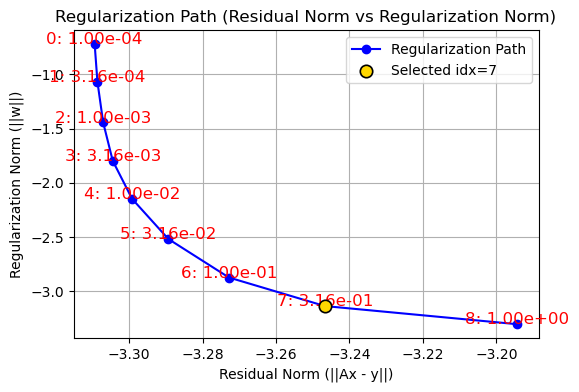

In [19]:
lamb_regu=np.logspace(-4,0,9,endpoint=True)
M0=models0.M
M_relu1,M_relu2=model_relu1.M,model_relu2.M
M_gauss1,M_gauss2=model_gauss1.M,model_gauss2.M
res,reg_norm,w_store=inverse_solver.L_curve(M0,M_relu1,M_relu2,M_gauss1,M_gauss2,"mixer",sum_mat,F_81_5_15,lamb_regu,cupy_device) # Solve first

In [20]:
Qx,Qy,Qz=150,150,150
sample_s=error_general_3d.test_p(Qx,Qy,Qz,0,1,0,1,0,1)
ratio1=[0.3,0.5,0.3]
ratio2=[0.5,0.5,0.8]

L-curve corner index: 7
Curvature-centered lambda window:
  idx=6, lambda=1.000000e-01, curvature=8.169202e-02
  idx=7, lambda=3.162278e-01, curvature=3.504364e-01 <== center
  idx=8, lambda=1.000000e+00, curvature=0.000000e+00
candidate idx: [6 7 8]
candidate lambda: [0.1        0.31622777 1.        ]
S_l_inf= 1.7536918053912414 S_L_2= 0.0001577829354084415 S_l_2= 0.019881097982820676


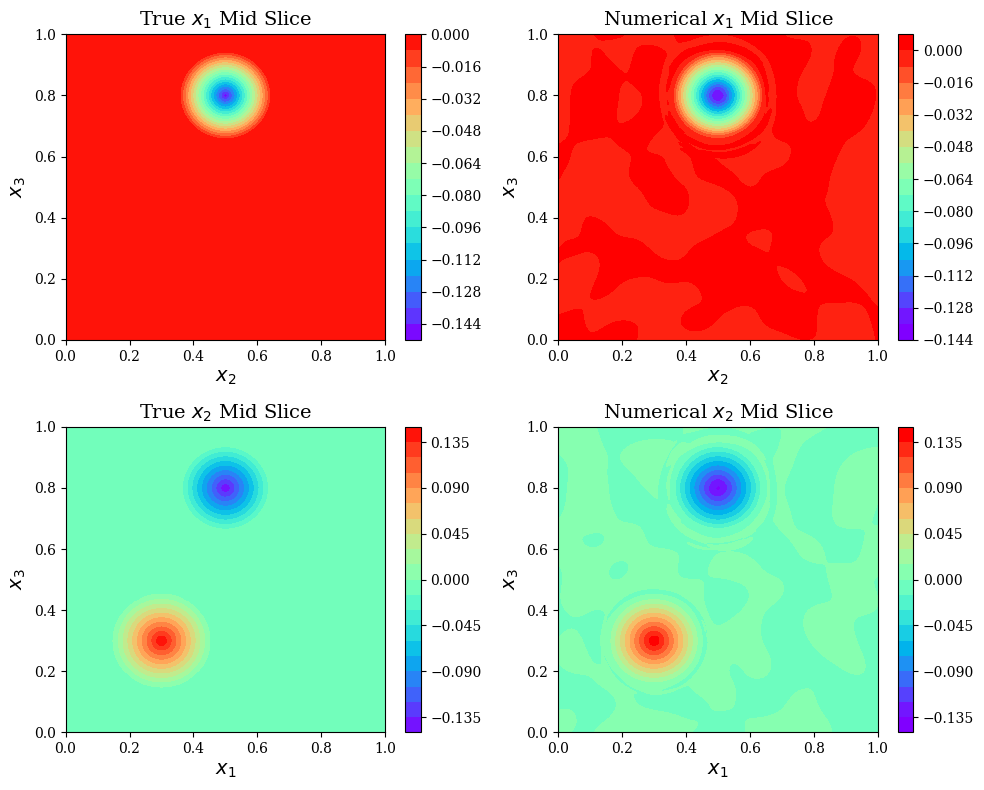

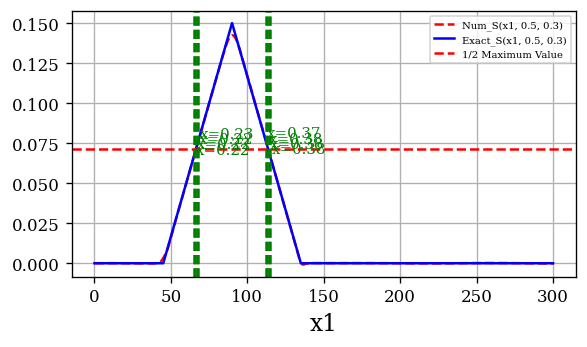

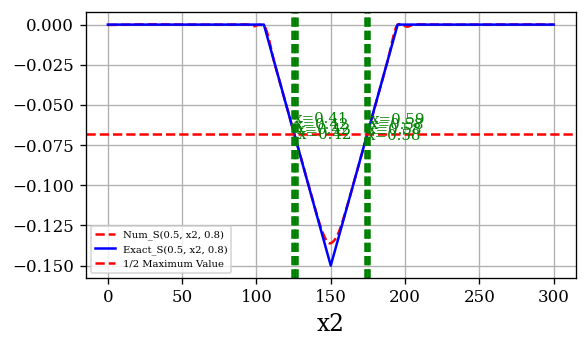

candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.7536918053912414, S_l_2=0.019881097982820676
S_l_inf= 1.8418569716504978 S_L_2= 0.00016209924893833993 S_l_2= 0.0204249657464058


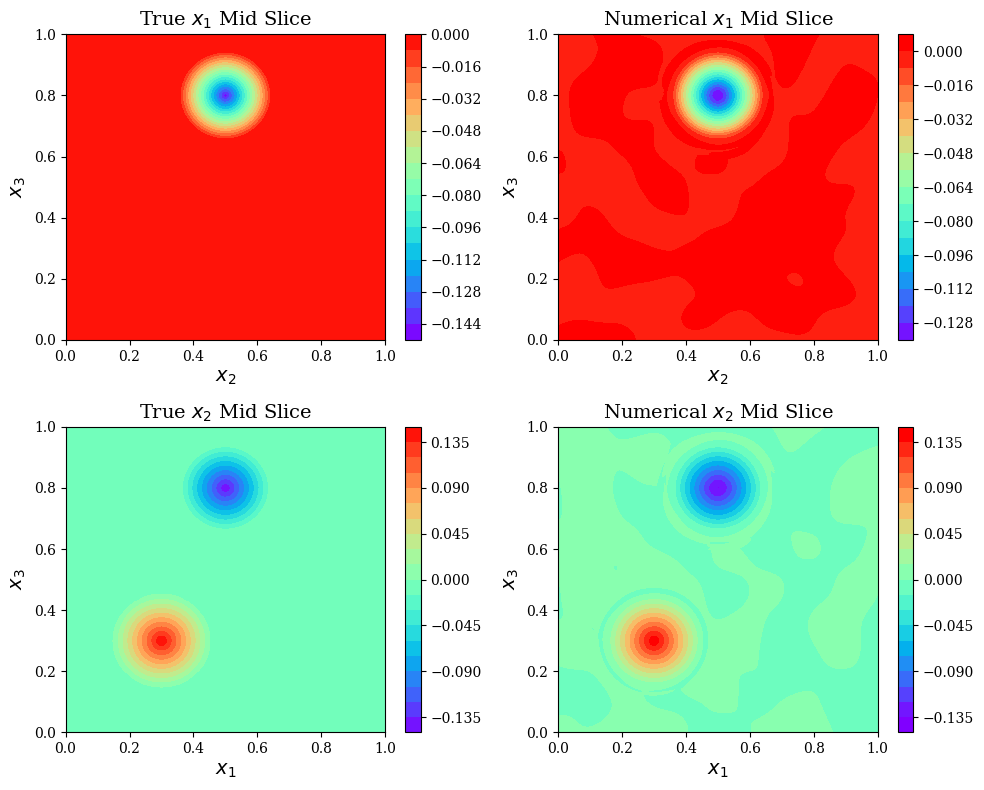

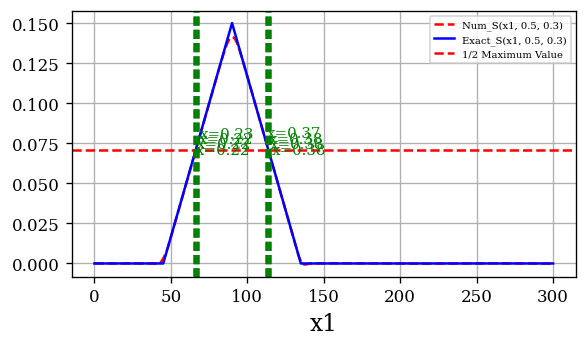

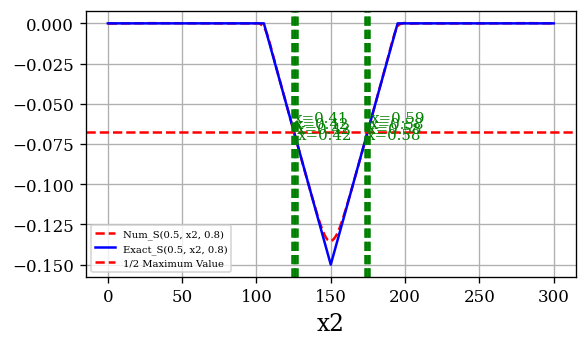

candidate idx=7, lamb=0.1, S_l_inf=1.8418569716504978, S_l_2=0.0204249657464058
S_l_inf= 1.9694499567894377 S_L_2= 0.00021204892013790413 S_l_2= 0.026718766180258566


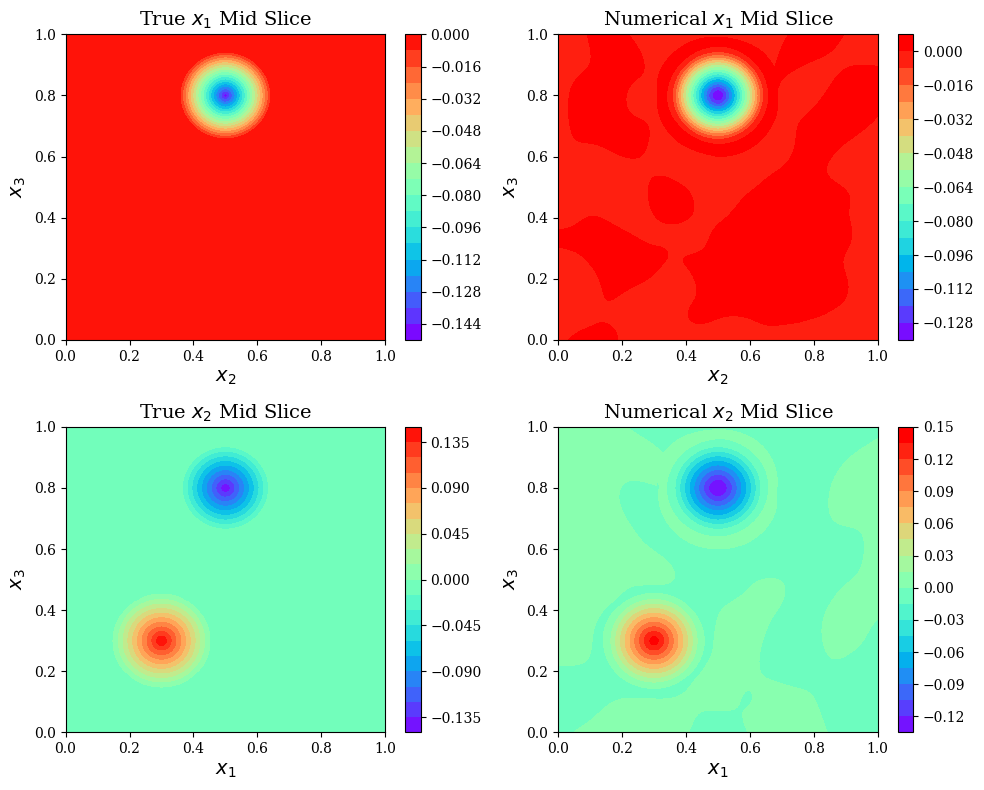

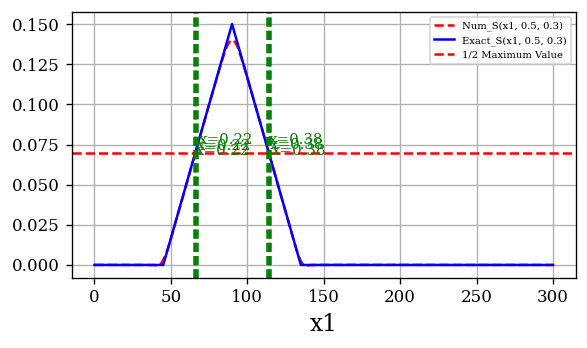

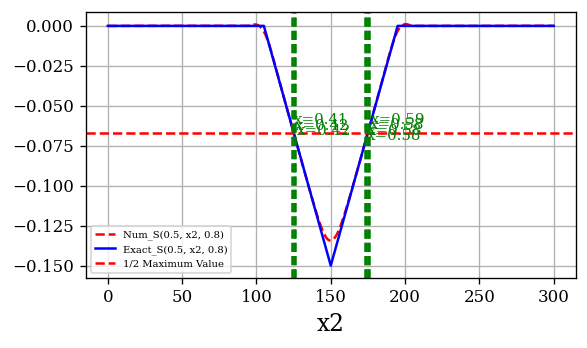

candidate idx=8, lamb=1.0, S_l_inf=1.9694499567894377, S_l_2=0.026718766180258566
picked idx: 6
lamb: 0.010000000000000002


In [21]:
reload(inverse_solver)
window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
    lamb_regu, res, reg_norm, radius=1, w_store=w_store
)
print('candidate idx:', window_idx)
print('candidate lambda:', window_lambda)
window_results = []
for local_i, cand_idx in enumerate(window_idx):
    cand_lamb = window_lambda[local_i]**2
    cand_w = window_w[:, local_i]
    result_tuple = error_general_3d.test(models0,model_relu1,model_relu2,model_gauss1,model_gauss2,sample_s,cand_w,"mixer",True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,[],[],[],[],center_true,r_true,ana_S,0,ratio1,ratio2,device)
    window_results.append({
        'idx': int(cand_idx),
        'lambda': cand_lamb,
        'w': cand_w,
        'result': result_tuple,
    })
    print(
        f"candidate idx={int(cand_idx)}, lamb={cand_lamb}, "
        f"S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}"
    )
pick = 0
picked = window_results[pick]
idx = picked['idx']
lamb = picked['lambda']
picked_w = picked['w']
S_num,S_true,S_l_inf,S_l_2,g_S=picked['result']
print('picked idx:', idx)
print('lamb:', lamb)


In [22]:
torch.save(model_relu1.state_dict(), f"{output_dir}/models_relu1_{lamb}.pth")
torch.save(model_relu2.state_dict(), f"{output_dir}/models_relu2_{lamb}.pth")
torch.save(model_gauss1.state_dict(), f"{output_dir}/models_gauss1_{lamb}.pth")
torch.save(model_gauss2.state_dict(), f"{output_dir}/models_gauss2_{lamb}.pth")


In [23]:
np.save(f"{output_dir}/S_num_{lamb}.npy",S_num)
np.save(f"{output_dir}/w_store_{lamb}.npy",w_store)
np.save(f"{output_dir}/sum_mat_{lamb}.npy",sum_mat)

In [24]:
n_integral=len(cells_store[-1])*27
print('n_integral:',n_integral)
print('center0:',center0)
print('half_axes0:', r0)
print('char_scale1:', char_scale1)
print('v1_physical, v1_nondim:', v1_physical, v1)
print('center1:',center1)
print('half_axes1:', r1)
print('char_scale2:', char_scale2)
print('v2_physical, v2_nondim:', v2_physical, v2)
print('lamb_regu:',lamb)
print('S_l21:',S_l_2)

n_integral: 21951
center0: [0.30003497 0.50093409 0.29907954]
half_axes0: [0.155 0.15  0.16 ]
char_scale1: 0.15494621789991567
v1_physical, v1_nondim: -15.405625 -0.36986333565765084
center1: [0.49906284 0.49938792 0.80000725]
half_axes1: [0.16 0.16 0.16]
char_scale2: 0.16
v2_physical, v2_nondim: -17.331328125 -0.44368199999999997
lamb_regu: 0.010000000000000002
S_l21: 0.019881097982820676
